In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_names = {'WTM3':'2024_11_12_0003.abf',
              'Bckdk':'2024_11_27_0017.abf',
              'USP7': '2024_12_02_0009.abf'}
sheet_names = {'WTM3': 'WT M3 C3 003.abf',
               'Bckdk': 'Bckdk KO M11 C3 017.abf ',
               'USP7': 'Usp7 Het M13 009.abf'}

consider = 'WTM3'
#data = pd.read_excel('AP_traces.xlsx', sheet_name=sheet_names[consider],
#                     usecols='B:O',  header=0, skiprows=[1])


In [20]:
from threshold_crossing import count_spikes
def show_rawdata(ax, currs=['15 pA', '25 pA', '35 pA']):
    for cc in currs:
        ax.plot(data['Time (ms)'] / 1000, 
                data[cc], 
                label=cc)
    ax.set_xlim(-0.1, 1.5)
    ax.set_ylim(-80, 50)
    ax.legend()
    return ax

def show_ficurve(ax, currs=['10 pA', '15 pA', '20 pA', '25 pA', '30 pA', '35 pA']):
    #ffs = []
    #cur_vals = []
    #for cc in currs:
    #    cur_vals.append(int(cc.strip('pA').strip()))
    #    ffs.append(count_spikes(np.array(data[cc])))
    #print(ffs)
    cur_vals = [10, 15, 20, 25, 30, 35]                                                                                                                                           
    ffs = [0, 0, 0, 8, 11, 11]
    ax.plot(cur_vals, ffs, label='Recording', c='k', marker='o')
    ax.set_ylim(-1, 30)
    ax.set_xlim(0, 50)
    return ax



In [23]:
model_test_currs = [10, 15, 20, 25]
cur_vals = [0, 5, 10, 15, 20, 25, 30, 35]                                                                                                                                           
ffs = [0, 0, 1, 4, 7, 9, 11, 12]

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from widgets_aut import *

Shrunk by 0.7
Using file Rorb-IRES2-Cre-D_Ai14_IVSCC_-168052.03.02.01_397999191_m_shrinked_0.7.swc
Shrunk axon by 0.5


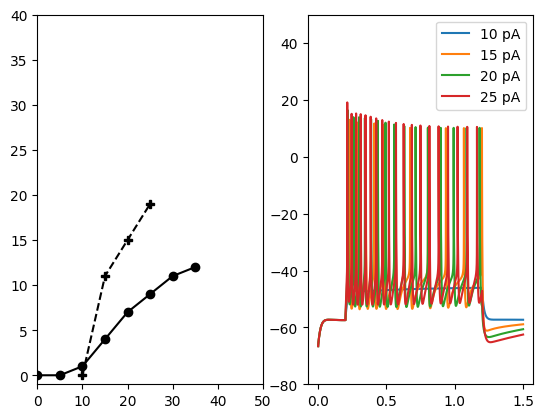

In [28]:
#from neuron472299294_250812 import Neuron472299294
import test_autism5 as utils
from neuron import h
h.celsius = 34.0
cell, results, clamp = utils.demo(model_test_currs)
ax1 = plt.subplot(121)
ax1 = utils.show_ficurve(ax1, results, 
                         defs=cur_vals, defs_ff=ffs)
ax2 = plt.subplot(122)
for res in results:
    tt, vv, ichs, amp = res
    ax2.plot(tt, vv, label=str(amp)+' pA')
    ax2.set_ylim(-80, 50)
    ax2.legend()

plt.show()

In [11]:
cm = pick_cm_range
g_pas = pick_gpas_range
ra = pick_Ra_range
pas_button = passivebutton

output_widget = widgets.Output()
def update_plot(b):
    pas_button.disabled = True
    pas_button.description = 'Computing...'
    pas_button.icon = 'spinner fa-spin'  # Using FontAwesome spinning icon
    with output_widget:
        clear_output(wait=True)
        cm_min, cm_max = cm.value
        gpas_min, gpas_max = g_pas.value
        ra_min, ra_max = ra.value      
        min_c, min_res, clamp = utils.demo(model_test_currs, {'cm': cm_min, 
                                                        'g_pas': gpas_min, 
                                                        'ra': ra_min})
        max_c, max_res, clamp = utils.demo(model_test_currs, {'cm': cm_max, 
                                                         'g_pas': gpas_max, 
                                                         'ra': ra_max})
        ax = plt.subplot()
        ax = utils.show_ficurve(ax, results, defs=cur_vals, defs_ff=ffs)
        ax = utils.show_ficurve(ax, min_res, color='b')
        ax = utils.show_ficurve(ax, max_res, color='r')
        plt.show()
    pas_button.disabled = False
    pas_button.description = 'Compute'
    pas_button.icon = 'check'  # Using FontAwesome spinning icon

#cm.observe(update_plot, names='value')
#g_pas.observe(update_plot, names='value')
#ra.observe(update_plot, names='value')

pas_button.on_click(update_plot)
ui = widgets.VBox([cm, g_pas, ra, pas_button, output_widget])
display(ui)


In [22]:
Na_T=pick_gbar_NaTs_range 
Na_P=pick_gbar_Nap_range
K_P=pick_gbar_K_P_range 
K_T=pick_gbar_K_T_range
Kv_3_1=pick_gbar_Kv_3_1_range 
SK=pick_gbar_SK_range
HVA=pick_gbar_Ca_HVA_range
LVA=pick_gbar_Ca_LVA_range
Im=pick_gbar_Im_range
Ih=pick_gbar_Ih_range
act_button=activebutton

output_widget2 = widgets.Output()
def update_plot2(b):
    act_button.disabled = True
    act_button.description = 'Computing...'
    act_button.icon = 'spinner fa-spin'  # Using FontAwesome spinning icon
    with output_widget:
        clear_output(wait=True)
        NaT_min, NaT_max = Na_T.value
        NaP_min, NaP_max = Na_P.value
        K_T_min, K_T_max = K_T.value
        K_P_min, K_P_max = K_P.value
        Kv3_1_min, Kv3_1_max = Kv_3_1.value
        SK_min, SK_max = SK.value
        HVA_min, HVA_max = HVA.value
        LVA_min, LVA_max = LVA.value
        Im_min, Im_max = Im.value
        Ih_min, Ih_max = Ih.value
        min_c, min_res, clp = utils.demo(model_test_currs, {'gbar_NaTs': NaT_min, 
                                                        'gbar_Nap': NaP_min, 
                                                        'gbar_K_P': K_P_min,
                                                        'gbar_K_T': K_T_min,
                                                        'gbar_Kv_3_1': Kv3_1_min,
                                                        'gbar_SK': SK_min,
                                                        'gbar_Ca_HVA': HVA_min,
                                                        'gbar_Ca_LVA': LVA_min,
                                                        'gbar_Ih': Ih_min,
                                                        'gbar_Im': Im_min})
        max_c, max_res, clp = utils.demo(model_test_currs, {'gbar_NaTs': NaT_max,
                                                        'gbar_Nap': NaP_max,
                                                        'gbar_K_P': K_P_max,
                                                        'gbar_K_T': K_T_max,
                                                        'gbar_Kv_3_1': Kv3_1_max,
                                                        'gbar_SK': SK_max,
                                                        'gbar_Ca_HVA': HVA_max,
                                                        'gbar_Ca_LVA': LVA_max,
                                                        'gbar_Ih': Ih_max,
                                                        'gbar_Im': Im_max})

        ax = plt.subplot()
        ax = utils.show_ficurve(ax, results, defs=cur_vals, defs_ff=ffs)
        ax = utils.show_ficurve(ax, min_res, color='b')
        ax = utils.show_ficurve(ax, max_res, color='r')
        plt.show()
    act_button.disabled = False
    act_button.description = 'Compute'
    act_button.icon = 'check'  # Using FontAwesome spinning icon

act_button.on_click(update_plot2)
ui2 = widgets.VBox([Na_T, Na_P, K_P, K_T, Kv_3_1, SK, 
                    HVA, LVA, Im, Ih, act_button, output_widget2])
display(ui2)

In [ ]:
consider = 'USP7'
data = pd.read_excel('AP_traces.xlsx', sheet_name=sheet_names[consider],
                     usecols='B:O',  header=0, skiprows=[1])

In [ ]:
rcParams['figure.figsize'] = 11 ,6
fig, ax = plt.subplots(1,2)
ax[0] = show_rawdata(ax[0])
ax[1] = make_plots(ax[1], results)

In [ ]:
rcParams['figure.figsize'] = 11 ,6
fig, ax = plt.subplots(1,2)
ax[0] = show_rawdata(ax[0])
ax[1] = make_plots(ax[1], results)